# 🧪 Lab 01: Perceptron e MLP do Zero com NumPy
**Módulo:** `02-deep-learning / neural-networks-from-scratch`

## Objetivos
1. Compreender a estrutura matemática de um neurônio artificial: $z = W \cdot X + b$.
2. Implementar funções de ativação: Sigmoide ($\sigma$) e ReLU.
3. Construir o ciclo de **Forward Pass** e o cálculo da função de perda (MSE).
4. Implementar o algoritmo de **Backpropagation** para atualização dos pesos via Gradiente Descendente.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 4)

## 1. Funções de Ativação e Suas Derivadas

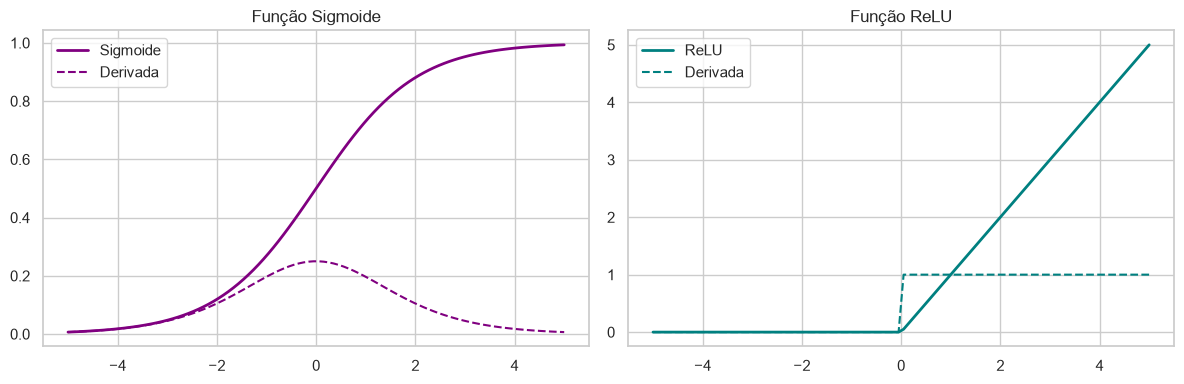

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Visualização das funções de ativação
x_vals = np.linspace(-5, 5, 100)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x_vals, sigmoid(x_vals), label='Sigmoide', color='purple', lw=2)
ax[0].plot(x_vals, sigmoid_derivative(x_vals), label='Derivada', color='purple', linestyle='--')
ax[0].set_title('Função Sigmoide')
ax[0].legend()

ax[1].plot(x_vals, relu(x_vals), label='ReLU', color='teal', lw=2)
ax[1].plot(x_vals, relu_derivative(x_vals), label='Derivada', color='teal', linestyle='--')
ax[1].set_title('Função ReLU')
ax[1].legend()

plt.tight_layout()
plt.show()

## 2. Implementação de um Multi-Layer Perceptron (MLP) Simples

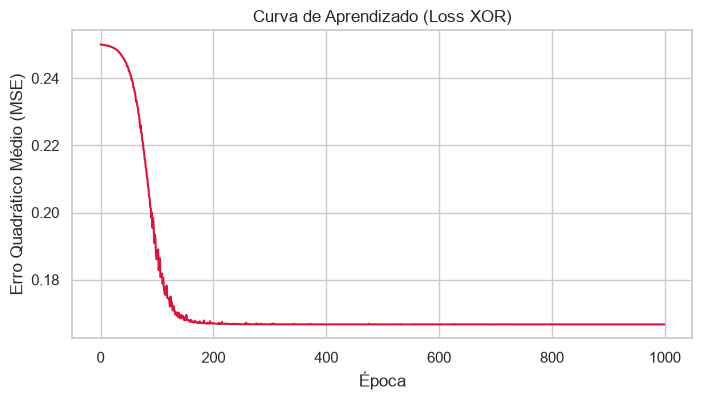

Previsões finais do modelo para o XOR:
[[0.67]
 [0.67]
 [0.67]
 [0.  ]]


In [3]:
class SimpleMLP:
    def __init__(self, input_size, hidden_size, output_size, lr=0.1):
        np.random.seed(42)
        # Pesos e Vieses (Biases)
        self.W1 = np.random.randn(input_size, hidden_size) * 0.1
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.1
        self.b2 = np.zeros((1, output_size))
        self.lr = lr

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output):
        m = X.shape[0]
        # Gradiente da camada de saída
        dz2 = output - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Gradiente da camada oculta
        dz1 = np.dot(dz2, self.W2.T) * relu_derivative(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Atualização dos pesos (Gradiente Descendente)
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

# Teste com o problema lógico XOR
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([[0], [1], [1], [0]])

mlp = SimpleMLP(input_size=2, hidden_size=4, output_size=1, lr=0.5)
perdas = []

for epoch in range(1000):
    output = mlp.forward(X_xor)
    loss = np.mean((output - y_xor) ** 2)
    perdas.append(loss)
    mlp.backward(X_xor, y_xor, output)

plt.plot(perdas, color='crimson')
plt.title('Curva de Aprendizado (Loss XOR)')
plt.xlabel('Época')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.show()

print("Previsões finais do modelo para o XOR:")
print(np.round(mlp.forward(X_xor), 2))